In [1]:
!pip install torch==2.2.2
!pip install psutil setuptools
!pip install "numpy<2"
!pip install evo-model --no-build-isolation

In [3]:
from evo import Evo

In [4]:
import torch
from tqdm import tqdm
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
file_path = "../Dataset_genomes/final_filtered_sequences.csv"
df = pd.read_csv(file_path, sep=',')

In [6]:
df.value_counts('species')

species
Escherichia phage       360
Pseudomonas phage       348
Staphylococcus phage    182
Klebsiella phage        171
Enterobacteria phage    156
Enterococcus phage       56
dtype: int64

In [7]:
df.head()

,id,sequence,species
0,NC_042134,CTAGTACACCACCTGTAGTAGGACAGGTGACAACGACAGAAACATC...,Enterococcus phage
1,NC_079184,CGATTATATGCGAGAAGAGATTCGATGCGTTAGCGTCGTTTCTCTT...,Escherichia phage
2,NC_079183,CGATTATATGCGAGAAGAGATTCGATGCGTTAGCGTCGTTTCTCTT...,Escherichia phage
3,NC_079182,ATGAAATCTAAGGAGAAGAAAGAAGCTAAAGCTCTGGTTAACCCGA...,Escherichia phage
4,NC_079181,ATGACTACTATCACCACTCAAACTATCAAATCCGTTGTTCCTGCTA...,Escherichia phage


In [8]:
import torch

print(f"CUDA device count: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")
    print(f"  Memory Allocated: {torch.cuda.memory_allocated(i) / 1024**3:.2f} GB")
    print(f"  Memory Reserved:  {torch.cuda.memory_reserved(i) / 1024**3:.2f} GB")

CUDA device count: 4
Device 0: NVIDIA L4
  Memory Allocated: 0.00 GB
  Memory Reserved:  0.00 GB
Device 1: NVIDIA L4
  Memory Allocated: 0.00 GB
  Memory Reserved:  0.00 GB
Device 2: NVIDIA L4
  Memory Allocated: 0.00 GB
  Memory Reserved:  0.00 GB
Device 3: NVIDIA L4
  Memory Allocated: 0.00 GB
  Memory Reserved:  0.00 GB


In [ ]:
evo_model = Evo('evo-1-8k-base')
model = evo_model.model
tokenizer = evo_model.tokenizer

In [9]:
import torch

print(f"CUDA device count: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")
    print(f"  Memory Allocated: {torch.cuda.memory_allocated(i) / 1024**3:.2f} GB")
    print(f"  Memory Reserved:  {torch.cuda.memory_reserved(i) / 1024**3:.2f} GB")

CUDA device count: 4
Device 0: NVIDIA L4
  Memory Allocated: 0.00 GB
  Memory Reserved:  0.00 GB
Device 1: NVIDIA L4
  Memory Allocated: 0.00 GB
  Memory Reserved:  0.00 GB
Device 2: NVIDIA L4
  Memory Allocated: 0.00 GB
  Memory Reserved:  0.00 GB
Device 3: NVIDIA L4
  Memory Allocated: 0.00 GB
  Memory Reserved:  0.00 GB


In [ ]:
import os
import torch
import json

save_path = "./evo-hf-model"
os.makedirs(save_path, exist_ok=True)

# === 模型部分 ===
model = evo_model.model
tokenizer = evo_model.tokenizer

# 保存权重
torch.save(model.state_dict(), os.path.join(save_path, "pytorch_model.bin"))

# 使用 tokenizer.vocab_size 构建 vocab 和设置 config
vocab_size = tokenizer.vocab_size
hidden_size = 4096  # 你也可以从 embedding 层提取

# 构建 vocab 列表
vocab = [tokenizer.decode_token(i) for i in range(vocab_size)]

# 构建 config.json
config = {
    "architectures": ["StripedHyenaForCausalLM"],
    "model_type": "stripedhyena",
    "hidden_size": hidden_size,
    "num_attention_heads": getattr(model, "num_attention_heads", 32),
    "num_hidden_layers": getattr(model, "num_hidden_layers", 32),
    "vocab_size": vocab_size,
    "torch_dtype": "bfloat16"
}
with open(os.path.join(save_path, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

# 保存 vocab.txt
with open(os.path.join(save_path, "vocab.txt"), "w", encoding="utf-8") as f:
    for token in vocab:
        f.write(token + "\n")

# 保存 tokenizer_config.json
tokenizer_config = {
    "tokenizer_class": "PreTrainedTokenizerFast",
    "model_max_length": getattr(tokenizer, "max_length", 8192),
    "unk_token": "<unk>",
    "bos_token": "<s>",
    "eos_token": "</s>",
    "pad_token": "<pad>"
}
with open(os.path.join(save_path, "tokenizer_config.json"), "w") as f:
    json.dump(tokenizer_config, f, indent=2)

# 保存 special_tokens_map.json
with open(os.path.join(save_path, "special_tokens_map.json"), "w") as f:
    json.dump({
        "unk_token": "<unk>",
        "bos_token": "<s>",
        "eos_token": "</s>",
        "pad_token": "<pad>"
    }, f, indent=2)

print("✅ 模型和 tokenizer 已成功打包为 Hugging Face 兼容格式，保存在:", save_path)

In [10]:
from transformers import PreTrainedModel, PretrainedConfig

class StripedHyenaConfig(PretrainedConfig):
    model_type = "stripedhyena"

class StripedHyenaWrapper(PreTrainedModel):
    config_class = StripedHyenaConfig

    def __init__(self, config):
        super().__init__(config)

        # 你自己的加载逻辑（这里你直接 new 一个模型实例）
        from evo import Evo
        self.model = Evo("evo-1-8k-base").model  # 注意不要加载 tokenizer

    def forward(self, *args, **kwargs):
        return self.model(*args, **kwargs)

import os
from transformers import PreTrainedTokenizer

class MyCharTokenizer(PreTrainedTokenizer):
    def __init__(self, vocab_file, **kwargs):
        with open(vocab_file, "r", encoding="utf-8") as f:
            vocab = [line.strip() for line in f.readlines()]
        self.vocab = vocab
        self.token_to_id = {t: i for i, t in enumerate(vocab)}
        self.id_to_token = {i: t for i, t in enumerate(vocab)}
        self.vocab_file = vocab_file
        super().__init__(**kwargs)

    def _tokenize(self, text):
        return list(text)  # 字符级分词

    def _convert_token_to_id(self, token):
        return self.token_to_id.get(token, self.token_to_id.get("<unk>"))

    def _convert_id_to_token(self, index):
        return self.id_to_token.get(index, "<unk>")

    def get_vocab(self):
        return self.token_to_id

    def save_vocabulary(self, save_directory, filename_prefix=None):
        out_path = os.path.join(save_directory, "vocab.txt")
        with open(out_path, "w", encoding="utf-8") as f:
            for token in self.vocab:
                f.write(token + "\n")
        return (out_path,)


In [19]:
from accelerate import dispatch_model
import torch
import json

device_map = {
    "model.embedding_layer": 1,  # 原本是 0
    "model.norm": 3,
    "model.unembed": 3,
}
for i in range(32):
    device_id = min((i // 8) + 1, 3)  # 限制最大值为 3
    device_map[f"model.blocks.{i}"] = device_id

# ✅ 先初始化模型时不放到任何 GPU（保持在 CPU）
model = StripedHyenaWrapper(config)

# ✅ 明确告诉 PyTorch：加载到 CPU
state_dict = torch.load("./evo-hf-model/pytorch_model.bin", map_location="cpu")

# ✅ 加载参数
model.model.load_state_dict(state_dict)

# ✅ 不要转 dtype，先 dispatch_model
model = dispatch_model(model, device_map=device_map)

# ✅ 分发后才手动转 dtype
for name, module in model.named_modules():
    try:
        module.to(torch.bfloat16)
    except:
        pass

print("✅ 模型已手动分配到多张 GPU，并转换为 bfloat16")

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

✅ 模型已手动分配到多张 GPU，并转换为 bfloat16


In [20]:
from collections import defaultdict
summary = defaultdict(list)
for name, p in model.named_parameters():
    summary[str(p.device)].append(name)

for d, keys in summary.items():
    print(f"📦 {d} has {len(keys)} tensors")

📦 cuda:1 has 113 tensors
📦 cuda:3 has 215 tensors
📦 cuda:2 has 107 tensors


In [59]:
def get_sequence_embedding(sequence: str):
    tokens = tokenizer.tokenize(sequence)
    input_ids = tokenizer.convert_tokens_to_ids(tokens)
    input_tensor = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0)

    embed_device = next(model.model.embedding_layer.parameters()).device
    input_tensor = input_tensor.to(embed_device)

    with torch.no_grad():
        hidden = model.model.embedding_layer(input_tensor)
        hidden_states, _ = model.model.stateless_forward(hidden)
        embedding = hidden_states.mean(dim=1).squeeze().cpu().float().numpy()
        return embedding

In [70]:
def get_batch_embedding(batch_sequences: list[str]):
    # 1. Encode → 获取 token ids（List[int]）
    input_ids = [tokenizer.encode(seq, add_special_tokens=False) for seq in batch_sequences]

    # 2. Padding
    max_len = max(len(ids) for ids in input_ids)
    input_ids = [ids + [tokenizer.pad_token_id] * (max_len - len(ids)) for ids in input_ids]

    # 3. 转 tensor
    input_tensor = torch.tensor(input_ids, dtype=torch.long).to(embed_device)

    # ✅ 4. 通过 embedding 层，变成浮点向量（B, L, D）
    embedded = model.model.embedding_layer(input_tensor)
    embedded = embedded.to(torch.bfloat16)


    # ✅ 5. 推理（跳过 unembed）
    with torch.no_grad():
        hidden_states, _ = model.model.stateless_forward(embedded)
        embeddings = hidden_states.mean(dim=1).to(torch.float32).cpu().numpy()

    return embeddings


BATCH_SIZE = 2
sequences = [seq[:2048] for seq in df['sequence']]
embeddings = []
embed_device = next(model.model.embedding_layer.parameters()).device

for i in tqdm(range(0, len(sequences), BATCH_SIZE), desc="Batch embedding"):
    batch = sequences[i:i+BATCH_SIZE]
    try:
        batch_embeddings = get_batch_embedding(batch)
        embeddings.extend(batch_embeddings)
    except RuntimeError as e:
        print(f"OOM at batch {i}, skipping. Error: {e}")
    torch.cuda.empty_cache()


embedding_matrix = np.vstack(embeddings)  # shape: (N, D)

Batch embedding: 100%|██████████| 637/637 [18:38<00:00,  1.76s/it]


In [73]:
embedding_df = pd.DataFrame(embedding_matrix)
embedding_df.insert(0, 'id', df['id'])
embedding_df.insert(1, 'species', df['species'])
embedding_df.to_csv('evo_sequence_embeddings_acc.csv', index=False)

In [74]:
df = pd.read_csv('evo_sequence_embeddings_acc.csv')
print(f"Total number of rows: {len(df)}")

Total number of rows: 1273


In [78]:
df.head()

,id,species,0,1,2,3,4,5,6,7,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,NC_042134,Enterococcus phage,13631488.0,8585216.0,1826816.0,134144.0,708608.0,-10289152.0,503808.0,14090240.0,...,1466368.0,6094848.0,1318912.0,-32128.0,25344.0,-509952.0,28442624.0,-7602176.0,10223616.0,-11141120.0
1,NC_079184,Escherichia phage,13500416.0,8650752.0,-399360.0,473088.0,643072.0,-8323072.0,309248.0,13303808.0,...,3162112.0,4128768.0,1343488.0,-409600.0,154624.0,-618496.0,29097984.0,-9043968.0,10420224.0,-12910592.0
2,NC_079183,Escherichia phage,13631488.0,8716288.0,-405504.0,471040.0,667648.0,-8323072.0,317440.0,13369344.0,...,3129344.0,4456448.0,1368064.0,-378880.0,140288.0,-598016.0,29360128.0,-9043968.0,10551296.0,-12910592.0
3,NC_079182,Escherichia phage,12976128.0,8192000.0,301056.0,350208.0,585728.0,-9109504.0,266240.0,13500416.0,...,2506752.0,3817472.0,1245184.0,-528384.0,205824.0,-614400.0,28966912.0,-8159232.0,10485760.0,-12058624.0
4,NC_079181,Escherichia phage,13172736.0,8454144.0,-532480.0,421888.0,573440.0,-7831552.0,149504.0,12845056.0,...,3096576.0,3358720.0,1269760.0,-573440.0,144384.0,-671744.0,28311552.0,-8978432.0,9895936.0,-12779520.0


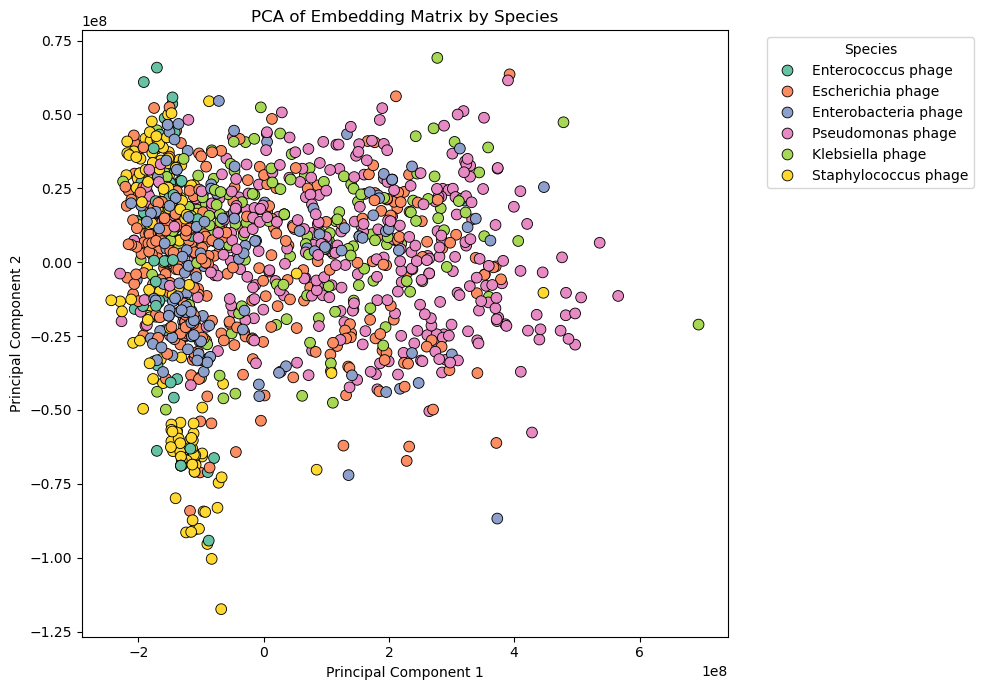

In [76]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(embedding_matrix)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'species': df['species']
})

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='species',
    palette='Set2',
    s=60,
    edgecolor='k'
)
plt.title('PCA of Embedding Matrix by Species')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

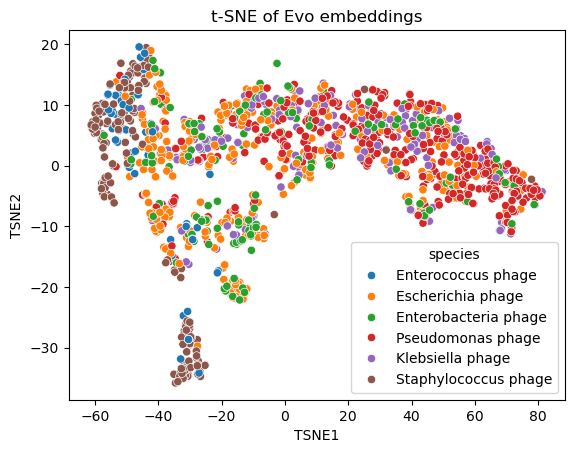

In [79]:
from sklearn.manifold import TSNE

X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(embedding_matrix)
tsne_df = pd.DataFrame({'TSNE1': X_tsne[:, 0], 'TSNE2': X_tsne[:, 1], 'species': df['species']})

sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='species')
plt.title('t-SNE of Evo embeddings')
plt.show()

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


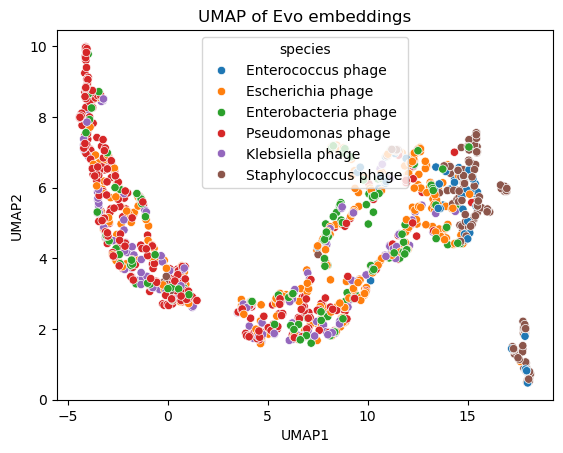

In [82]:
!pip install umap-learn

import umap.umap_ as umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(embedding_matrix)
umap_df = pd.DataFrame({'UMAP1': X_umap[:, 0], 'UMAP2': X_umap[:, 1], 'species': df['species']})

sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='species')
plt.title('UMAP of Evo embeddings')
plt.show()


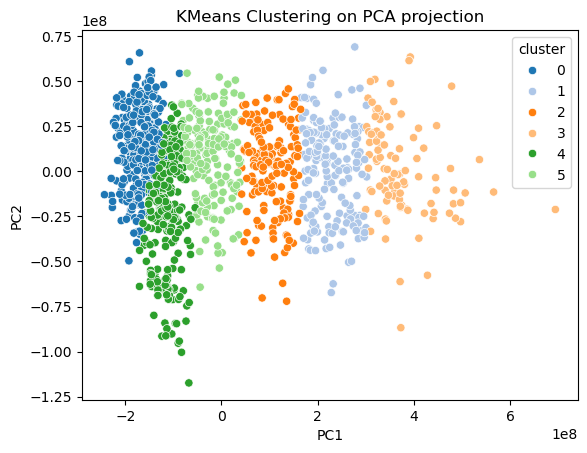

In [83]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=df['species'].nunique(), random_state=42)
clusters = kmeans.fit_predict(embedding_matrix)

df['cluster'] = clusters

pca_df['cluster'] = clusters
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='tab20')
plt.title('KMeans Clustering on PCA projection')
plt.show()

In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    embedding_matrix, df['species'], test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

Enterobacteria phage       0.63      0.36      0.46        33
  Enterococcus phage       0.50      0.62      0.56         8
   Escherichia phage       0.54      0.71      0.61        66
    Klebsiella phage       0.57      0.38      0.46        34
   Pseudomonas phage       0.70      0.71      0.71        77
Staphylococcus phage       0.89      0.89      0.89        37

            accuracy                           0.65       255
           macro avg       0.64      0.61      0.61       255
        weighted avg       0.65      0.65      0.64       255



<Axes: xlabel='PC1', ylabel='PC2'>

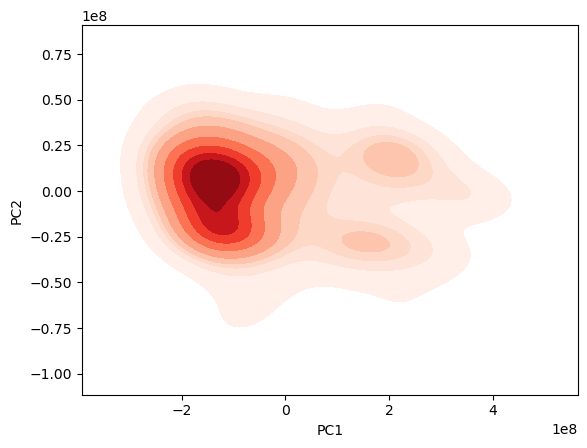

In [86]:
subset = pca_df[pca_df['species'] == 'Escherichia phage']
sns.kdeplot(data=subset, x='PC1', y='PC2', fill=True, cmap="Reds")

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np

# 1. 标签编码
le = LabelEncoder()
y = le.fit_transform(df['species'])

# 2. 原始数据划分给 XGBoost（4096维）
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    embedding_matrix, y, test_size=0.2, random_state=42
)

# 3. 标准化 + PCA 降维（用于 LGBM / SVM / MLP）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(embedding_matrix)

pca = PCA(n_components=200)
X_pca = pca.fit_transform(X_scaled)

# 降维后划分（必须保持顺序一致）
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca, y, test_size=0.3， random_state=42)

# ================================
# A. 原始高维模型：XGBoost
# ================================
xgb_clf = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_clf.fit(X_train_raw, y_train)

# ================================
# B. 降维后模型：LGBM / SVM / MLP
# ================================

lgbm_clf = LGBMClassifier(random_state=42)
lgbm_clf.fit(X_train_pca, y_train)

svm_clf = SVC(kernel='rbf', probability=True, random_state=42)
svm_clf.fit(X_train_pca, y_train)

mlp_clf = MLPClassifier(hidden_layer_sizes=(256, 64), max_iter=500, random_state=42)
mlp_clf.fit(X_train_pca, y_train)

# ================================
# Voting 集成预测（Soft Voting）
# ================================

# 各模型概率预测（注意输入维度要一致）
y_pred_xgb = xgb_clf.predict_proba(X_test_raw)
y_pred_lgbm = lgbm_clf.predict_proba(X_test_pca)
y_pred_svm = svm_clf.predict_proba(X_test_pca)
y_pred_mlp = mlp_clf.predict_proba(X_test_pca)

# Soft voting：平均概率
y_pred_proba_avg = (y_pred_xgb + y_pred_lgbm + y_pred_svm + y_pred_mlp) / 4
y_pred_ensemble = np.argmax(y_pred_proba_avg, axis=1)

# ================================
# 评估指标输出
# ================================
print(classification_report(y_test, y_pred_ensemble, target_names=le.classes_))
accuracy = accuracy_score(y_test, y_pred_ensemble)
print(f"\n✅ Voting Ensemble Accuracy: {accuracy:.4f}")


ValueError: Found input variables with inconsistent numbers of samples: [891, 1018]

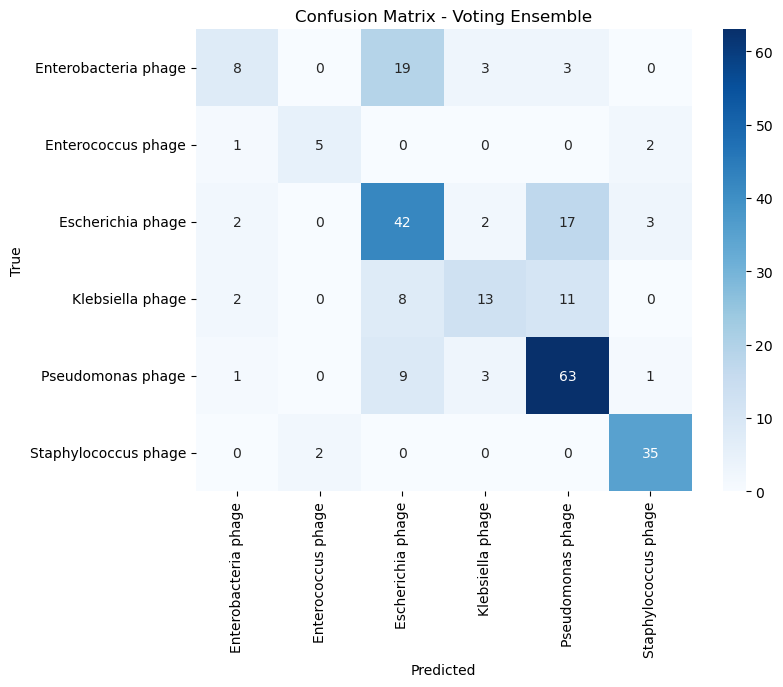

In [98]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Voting Ensemble")
plt.show()

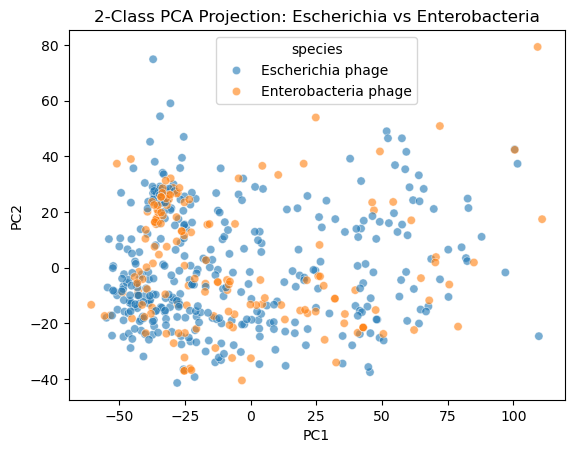

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 只取前两个主成分
X_pca_2d = X_pca[:, :2]

# 构建 dataframe
pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_df['species'] = le.inverse_transform(y)

# 选出感兴趣的两个类别
subset = pca_df[pca_df['species'].isin(['Escherichia phage', 'Enterobacteria phage'])]

# 绘图
sns.scatterplot(data=subset, x='PC1', y='PC2', hue='species', alpha=0.6)
plt.title("2-Class PCA Projection: Escherichia vs Enterobacteria")
plt.show()

In [93]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(hidden_layer_sizes=(256, 64), max_iter=500, random_state=42)
clf.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(256, 64), max_iter=500, random_state=42)